# curbage_fMRI Figures
## Aging reduces shared event structure at encoding, weakening memory reinstatement in the Posterior Medial Network
### Angelique I. Delarazan, Charan Ranganath, Zachariah M. Reagh

### Set Up

#### Import packages

In [36]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from nilearn import plotting
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

### Functions

In [145]:
def sig_stars(p):
    if p < .001: return '***'
    elif p < .01: return '**'
    elif p < .05: return '*'
    else: return ''

group_color = {
    'younger': '#91333d',
    'older': '#2b3f67',
}

group_order = ['younger', 'older']
group_labels = {
    'younger': 'Younger\nAdults',
    'older': 'Older\nAdults',
}

group_labels_single = {
    'younger': 'Younger Adults',
    'older': 'Older Adults'
}

comparison_order = ['within', 'cross']
comparison_labels = {
    'within': 'Within-Age\nGroup',
    'cross': 'Cross-Age\nGroup'
}

legend_labels = {
    'younger': 'Younger Adults',
    'older': 'Older Adults'
}

#### Path Directories

In [64]:
base_dir = '/Volumes/omega/curbage_fMRI/'
data_dir = os.path.join(base_dir, 'data/')
roi_dir = '/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/data/rois'
beh_dir = os.path.join(data_dir, 'beh/')
preprocessed_dir = os.path.join(data_dir, f'preprocessed/')
analyses_dir = os.path.join(data_dir, f'analyses/')

with open('/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/github/data/curbage_fMRI_sub-all_group-all.txt', 'r') as f:
    subjects = [line.strip() for line in f if line.strip()]

TRshift = 5
TRs = 1.22
min_tr = 1270
desc = 'preproc_bold_motion06_zscore_detrend'
group_dict = {sub: 'older' if int(sub) > 100 else 'younger' for sub in subjects}
bold_path_template = 'sub-{}/func/sub-{}_task-encoding_space-fsaverage_hemi-{}_desc-preproc_bold_motion06_zscore_detrend_network-PMN.npy'
np.random.seed(42)

### Recall Specificity

\begin{equation*}
Specificity Ratio = 1+\frac{{(Detail Units - Gist Units)}} {{(Detail Units + Gist Units)}}
\end{equation*}

In [65]:
beh = pd.read_pickle('~/Box Sync/aidelarazan_box/Projects/curbage_fMRI/github/data/curbage_fMRI_sub-all_group-all_task-beh_desc-SpecifcityRatio.pkl')
beh['subject'] = beh['subject'].astype(str).str.zfill(2)
beh['specificity_ratio'] = 1+ ((beh['detail_unit']-beh['gist_unit'])/(beh['detail_unit']+beh['gist_unit']))
beh.head()

,subject,group,gist_unit,detail_unit,specificity_ratio
0,03,younger,62,52,0.912281
1,04,younger,73,64,0.934307
2,05,younger,43,38,0.938272
3,06,younger,37,28,0.861538
4,07,younger,46,37,0.891566


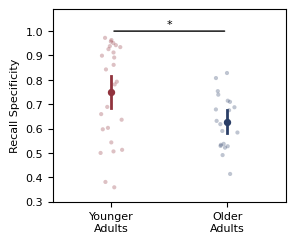

In [154]:
fig, ax = plt.subplots(figsize=(3, 2.5), facecolor='none')

sns.pointplot(
    data=beh,
    x='group',
    y='specificity_ratio',
    hue='group',
    palette=group_color, 
    order=group_order,
    ci=95,  
    markers='o',           
    scale=.6,             
    capsize=0,
    linestyles='none',
    join=False 
)

for line in ax.lines:
    line.set_linewidth(2)

sns.stripplot(
    data=beh,
    x='group',
    hue='group',
    y='specificity_ratio',
    palette=group_color, 
    edgecolor="black",
    size=3, 
    jitter=1, 
    zorder=0,
    alpha=0.3,
    order=group_order
)

ax.legend_.remove()
ax.set_ylabel('Recall Specificity', fontsize=8)
ax.set_xlabel('')
ax.set_xticks(range(len(group_order)))
ax.set_xticklabels([group_labels[label] for label in group_order])

xy = (0, 1)
xytext = (1, 1)
center = ((xy[0] + xytext[0]) / 2, (xy[1] + xytext[1]) / 2)

ax.annotate('', xy=xy, xytext=xytext, arrowprops=dict(arrowstyle='-', color='black'))
ax.text(center[0], center[1] + .009, '*', ha='center', va='bottom', fontsize=8)
ax.set_ylim(0.3, 1.09)
ax.tick_params(labelsize=8)
# plt.savefig('/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures/curbage_fMRI_desc-RecallSpecificity.png', dpi=300, bbox_inches='tight')
plt.show()

### Pattern Reinstatement

In [67]:
reinstatement = pd.read_pickle(f'~/Box Sync/aidelarazan_box/Projects/curbage_fMRI/github/data/curbage_fMRI_sub-all_group-all_task-all_space-fsaverage_desc-preproc_bold_motion06_zscore_detrend_5TRshift_PatternReinstatement.pkl')
reinstatement = reinstatement.groupby(['subject', 'network', 'group', 'comparison', 'match'], as_index=False)['fisher_z'].mean()
reinstatement['subject'] = reinstatement['subject'].astype(str).str.zfill(2)

reinstatement = reinstatement.pivot_table(
    index=['subject', 'group', 'network', 'comparison'],
    columns='match',
    values='fisher_z'
).reset_index()

reinstatement['ps'] = reinstatement['matched'] - reinstatement['mismatched']
reinstatement = reinstatement[['subject', 'group', 'network', 'comparison', 'ps']].reset_index(drop=True)
reinstatement.head()

match,subject,group,network,comparison,ps
0,03,younger,PMN,within,-0.010223
1,04,younger,PMN,within,0.002637
2,05,younger,PMN,within,-0.008126
3,06,younger,PMN,within,0.072231
4,07,younger,PMN,within,-0.011994


#### Point and Strip Plot

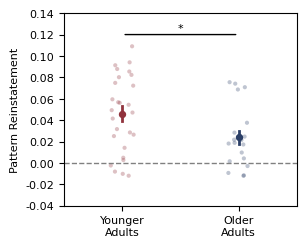

In [ ]:
fig, ax = plt.subplots(figsize=(3, 2.5), facecolor='none')

sns.pointplot(
    data=reinstatement,
    x='group',
    y='ps',
    hue='group',
    palette=group_color, 
    order=group_order,
    ci=95,
    markers='o',           
    scale=.6,             
    capsize=0,
    linestyles='none',
    join=False
)

for line in ax.lines:
    line.set_linewidth(2)

sns.stripplot(
    data=reinstatement,
    x='group',
    y='ps',
    hue='group',
    palette=group_color, 
    edgecolor="black",
    size=3, 
    jitter=1, 
    zorder=0,
    alpha=0.3,
    order=group_order
)

ax.legend_.remove()
ax.set_ylabel('Pattern Reinstatement', fontsize=8)
ax.set_xlabel('')
ax.set_xticks(range(len(group_order)))
ax.set_xticklabels([group_labels[label] for label in group_order])
xy = (0, .12)
xytext = (1, .12)
center = ((xy[0] + xytext[0]) / 2, (xy[1] + xytext[1]) / 2)

ax.annotate('', xy=xy, xytext=xytext, arrowprops=dict(arrowstyle='-', color='black'))
ax.text(center[0], center[1] + .001, '*', ha='center', va='bottom', fontsize=8)
ax.set_ylim(-.04, 0.14)
ax.set_yticks(np.arange(-0.04, 0.16, 0.02))
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, zorder=1)
ax.tick_params(labelsize=8)
ax.set_yticklabels([f'{tick:.2f}' for tick in ax.get_yticks()])
# plt.savefig('/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures_2026.02.25/curbage_fMRI_desc-RSA.png', dpi=300, bbox_inches='tight')
plt.show()

#### Brain Figures

In [17]:
brain_reinstatement = pd.read_pickle('/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/github/data/curbage_fMRI_sub-all_group-all_task-all_space-fsaverage_desc-preproc_bold_motion06_zscore_detrend_5TRshift_PatternReinstatement_Parcels.pkl')
brain_reinstatement = brain_reinstatement.groupby(['subject', 'hemi', 'network', 'parcel', 'group', 'comparison', 'match'], as_index=False)['fisher_z'].mean()
brain_reinstatement['subject'] = brain_reinstatement['subject'].astype(str).str.zfill(2)

brain_reinstatement = brain_reinstatement.pivot_table(
    index=['subject', 'group', 'hemi', 'network', 'parcel', 'comparison'],
    columns='match',
    values='fisher_z'
).reset_index()

brain_reinstatement['ps'] = brain_reinstatement['matched'] - brain_reinstatement['mismatched']
brain_reinstatement = brain_reinstatement[['subject', 'group', 'hemi', 'network', 'parcel', 'comparison', 'ps']].reset_index(drop=True)
brain_reinstatement

match,subject,group,hemi,network,parcel,comparison,ps
0,03,younger,lh,PMN,L_31a,within,0.078689
1,03,younger,lh,PMN,L_31pd,within,0.039531
2,03,younger,lh,PMN,L_31pv,within,0.038166
3,03,younger,lh,PMN,L_7m,within,0.008631
4,03,younger,lh,PMN,L_8Ad,within,-0.016132
...,...,...,...,...,...,...,...
1099,45,younger,rh,PMN,R_PGs,within,0.066528
1100,45,younger,rh,PMN,R_RSC,within,0.007671
1101,45,younger,rh,PMN,R_d23ab,within,0.070777
1102,45,younger,rh,PMN,R_p10p,within,0.113740


In [19]:
brain_reinstatement_group = brain_reinstatement.groupby(['group', 'hemi', 'parcel'])['ps'].mean().reset_index()
brain_reinstatement_group.head()

,group,hemi,parcel,ps
0,older,lh,L_31a,0.007017
1,older,lh,L_31pd,0.037895
2,older,lh,L_31pv,0.052018
3,older,lh,L_7m,0.028492
4,older,lh,L_8Ad,0.023592


In [27]:
plot_group = 'younger'

min_val = -0.02
max_val = 0.06

lh_data = np.full(163842, np.nan)
rh_data = np.full(163842, np.nan)

#### Medial (RH)

/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/2211168852.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_stat_map(


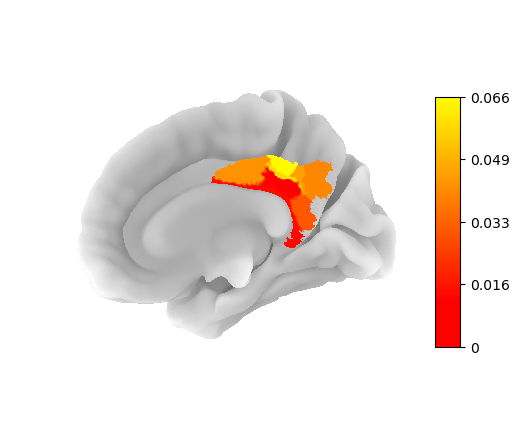

In [28]:
for _, row in brain_reinstatement_group[brain_reinstatement_group['group']==plot_group].iterrows():
    network = row['parcel']
    hemi = row['hemi']
    avg_value = row['ps']
    
    mask_file = f"{roi_dir}/sub-all/surface/sub-all_space-fsaverage_hemi-{hemi}_desc-HCPMMP1_parcel-{network}.npy"
    mask = np.load(mask_file)
    
    if hemi == 'lh':
        lh_data[mask] = avg_value
    else:
        rh_data[mask] = avg_value

fig = plotting.plot_surf_stat_map(
    surf_mesh=f'{roi_dir}/sub-all/surface/rh.pial',
    stat_map=rh_data,
    hemi='right',
    view='medial',
    colorbar=True,
    cmap='autumn',
    # vmin=min_val,
    # vmax=max_val,
    symmetric_cbar=False,
    bg_map=f'{roi_dir}/sub-all/surface/rh.sulc',
    figure=plt.figure(figsize=(5, 5), facecolor='none'),
    alpha=2
)

fig.axes[0].patch.set_alpha(0)
# plt.savefig(f'/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures/curbage_fMRI_desc-RSA_{plot_group}_BrainRightMedial.png', dpi=300, bbox_inches='tight', transparent=True, facecolor='none')
plt.show()

#### Medial (LH)

Skipping L_RSC due to visual artifacts


/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/3610923338.py:19: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_stat_map(


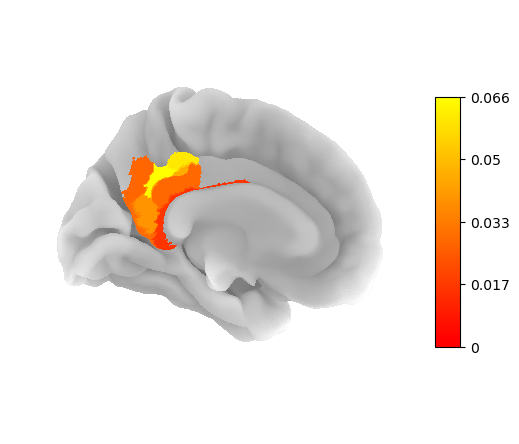

In [31]:
for _, row in brain_reinstatement_group[brain_reinstatement_group['group']==plot_group].iterrows():
    network = row['parcel']
    hemi = row['hemi']
    avg_value = row['ps']
    
    if network == 'L_RSC':
        print(f"Skipping {network} due to visual artifacts")
        continue
    
    mask_file = f"{roi_dir}/sub-all/surface/sub-all_space-fsaverage_hemi-{hemi}_desc-HCPMMP1_parcel-{network}.npy"
    mask = np.load(mask_file)
    indices = np.where(mask)[0]
    
    if hemi == 'lh':
        lh_data[indices] = avg_value
    else:
        rh_data[indices] = avg_value

fig = plotting.plot_surf_stat_map(
    surf_mesh=f'{roi_dir}/sub-all/surface/lh.pial',
    stat_map=lh_data,
    hemi='left',
    view='medial',
    colorbar=True,
    cmap='autumn',
    # vmin=min_val,
    # vmax=max_val,
    symmetric_cbar=False,
    bg_map=f'{roi_dir}/sub-all/surface/lh.sulc',
    figure=plt.figure(figsize=(5, 5), facecolor='none'),
    alpha=2
)

fig.axes[0].patch.set_alpha(0)
# plt.savefig(f'/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures/curbage_fMRI_desc-RSA_{group_to_plot}_BrainLeftMedial.png', dpi=300, bbox_inches='tight', transparent=True, facecolor='none')
plt.show()

#### Lateral (LH)

/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/3542733101.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_stat_map(


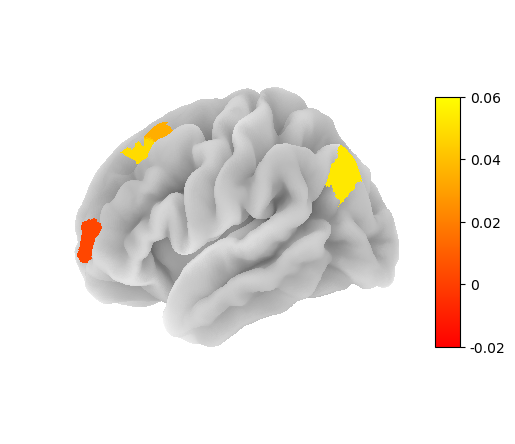

In [33]:
for _, row in brain_reinstatement_group[(brain_reinstatement_group['group']==plot_group)].iterrows():
    network = row['parcel']
    hemi = row['hemi']
    avg_value = row['ps']
    
    mask_file = f"{roi_dir}/sub-all/surface/sub-all_space-fsaverage_hemi-{hemi}_desc-HCPMMP1_parcel-{network}.npy"
    mask = np.load(mask_file)
    
    if hemi == 'lh':
        lh_data[mask] = avg_value
    else:
        rh_data[mask] = avg_value

fig = plotting.plot_surf_stat_map(
    surf_mesh=f'{roi_dir}/sub-all/surface/lh.pial',
    stat_map=lh_data,
    hemi='left',
    view='lateral',
    colorbar=True,
    cmap='autumn',
    vmin=min_val,
    vmax=max_val,
    symmetric_cbar=False,
    bg_map=f'{roi_dir}/sub-all/surface/lh.sulc',
    figure=plt.figure(figsize=(5, 5), facecolor='none'),
    alpha=2
)

# Make axes background transparent
fig.axes[0].patch.set_alpha(0)
# plt.savefig(f'/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures/curbage_fMRI_desc-RSA_{plot_group}_BrainLeftLateral.png', dpi=300, bbox_inches='tight', transparent=True, facecolor='none')
plt.show()

#### Lateral (RH)

/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/3082645855.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_stat_map(


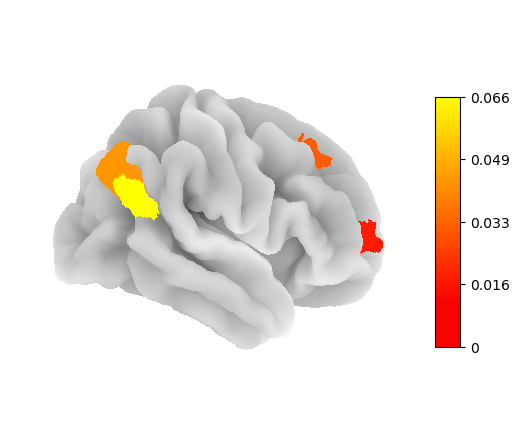

In [35]:
for _, row in brain_reinstatement_group[(brain_reinstatement_group['group']==plot_group)].iterrows():
    network = row['parcel']
    hemi = row['hemi']
    avg_value = row['ps']
    
    mask_file = f"{roi_dir}/sub-all/surface/sub-all_space-fsaverage_hemi-{hemi}_desc-HCPMMP1_parcel-{network}.npy"
    mask = np.load(mask_file)
    
    if hemi == 'lh':
        lh_data[mask] = avg_value
    else:
        rh_data[mask] = avg_value

fig = plotting.plot_surf_stat_map(
    surf_mesh=f'{roi_dir}/sub-all/surface/rh.pial',
    stat_map=rh_data,
    hemi='right',
    view='lateral',
    colorbar=True,
    cmap='autumn',
    symmetric_cbar=False,
    # vmin=min_val,
    # vmax=max_val,
    bg_map=f'{roi_dir}/sub-all/surface/rh.sulc',
    figure=plt.figure(figsize=(5, 5), facecolor='none'),
    alpha=2
)

fig.axes[0].patch.set_alpha(0)
# plt.savefig(f'/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures/curbage_fMRI_desc-RSA_{plot_group}_BrainRightLateral.png', dpi=300, bbox_inches='tight', transparent=True, facecolor='none')
plt.show()

/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/759294569.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('autumn')


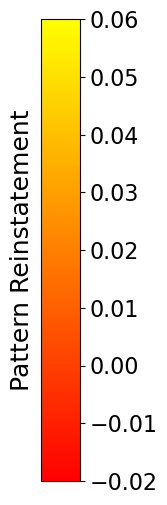

In [37]:
fig, ax = plt.subplots(figsize=(0.5, 6), facecolor='none')

cmap = cm.get_cmap('autumn')
norm = plt.Normalize(vmin=min_val, vmax=max_val)

cbar = fig.colorbar(
    cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=ax,
    orientation='vertical'
)

cbar.ax.tick_params(labelsize=16)
cbar.ax.text(-0.5, 0.5, 'Pattern Reinstatement', 
             ha='center', va='center', 
             transform=cbar.ax.transAxes, fontsize=18, rotation=90)
ax.patch.set_alpha(0)

# plt.savefig(
#     '/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures/curbage_fMRI_desc-RSA_colorbar.png',
#     dpi=300,
#     bbox_inches='tight',
#     transparent=True,
#     facecolor='none',
#     pad_inches=0.1
# )

plt.show()

#### Group Difference

In [43]:
# min_val = -0.02
# max_val = 0.06

In [44]:
brain_reinstatement_oa = brain_reinstatement_group[brain_reinstatement_group['group']=='older']
brain_reinstatement_ya = brain_reinstatement_group[brain_reinstatement_group['group']=='younger']

brain_reinstatement_diff = brain_reinstatement_oa.merge(
    brain_reinstatement_ya,
    on=['hemi', 'parcel'],
    suffixes=('_oa', '_ya')
)

brain_reinstatement_diff['group_diff'] = brain_reinstatement_diff['ps_ya'] - brain_reinstatement_diff['ps_oa']
brain_reinstatement_diff.head()

,group_oa,hemi,parcel,ps_oa,group_ya,ps_ya,group_diff
0,older,lh,L_31a,0.007017,younger,0.060725,0.053708
1,older,lh,L_31pd,0.037895,younger,0.066295,0.028399
2,older,lh,L_31pv,0.052018,younger,0.045582,-0.006436
3,older,lh,L_7m,0.028492,younger,0.027618,-0.000874
4,older,lh,L_8Ad,0.023592,younger,0.048509,0.024916


/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/1371575238.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_stat_map(


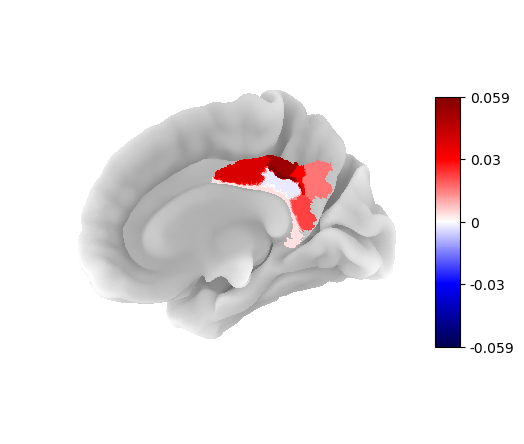

In [46]:
for _, row in brain_reinstatement_diff.iterrows():
    network = row['parcel']
    hemi = row['hemi']
    avg_value = row['group_diff']
    
    mask_file = f"{roi_dir}/sub-all/surface/sub-all_space-fsaverage_hemi-{hemi}_desc-HCPMMP1_parcel-{network}.npy"
    mask = np.load(mask_file)
    
    if hemi == 'lh':
        lh_data[mask] = avg_value
    else:
        rh_data[mask] = avg_value

fig = plotting.plot_surf_stat_map(
    surf_mesh=f'{roi_dir}/sub-all/surface/rh.pial',
    stat_map=rh_data,
    hemi='right',
    view='medial',
    colorbar=True,
    cmap='seismic',
    # vmin=min_val,
    # vmax=max_val,
    symmetric_cbar=True,
    bg_map=f'{roi_dir}/sub-all/surface/rh.sulc',
    figure=plt.figure(figsize=(5, 5), facecolor='none'),
    alpha=2
)

fig.axes[0].patch.set_alpha(0)
# plt.savefig('/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures/curbage_fMRI_desc-RSA_YA-OAs_BrainRightMedial.png', dpi=300, bbox_inches='tight', transparent=True, facecolor='none')
plt.show()

Skipping L_RSC due to visual artifacts


/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/1433570583.py:19: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_stat_map(


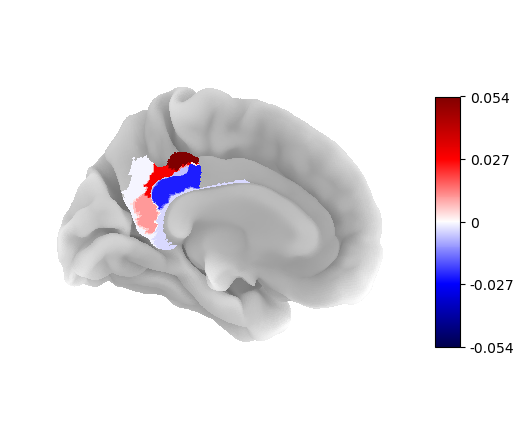

In [48]:
for _, row in brain_reinstatement_diff.iterrows():
    network = row['parcel']
    hemi = row['hemi']
    avg_value = row['group_diff']
    
    if network == 'L_RSC':
        print(f"Skipping {network} due to visual artifacts")
        continue
    
    mask_file = f"{roi_dir}/sub-all/surface/sub-all_space-fsaverage_hemi-{hemi}_desc-HCPMMP1_parcel-{network}.npy"
    mask = np.load(mask_file)
    indices = np.where(mask)[0]
    
    if hemi == 'lh':
        lh_data[indices] = avg_value
    else:
        rh_data[indices] = avg_value

fig = plotting.plot_surf_stat_map(
    surf_mesh=f'{roi_dir}/sub-all/surface/lh.pial',
    stat_map=lh_data,
    hemi='left',
    view='medial',
    colorbar=True,
    cmap='seismic',
    # vmin=min_val,
    # vmax=max_val,
    symmetric_cbar=True,
    bg_map=f'{roi_dir}/sub-all/surface/lh.sulc',
    figure=plt.figure(figsize=(5, 5), facecolor='none'),
    alpha=2
)

fig.axes[0].patch.set_alpha(0)
# plt.savefig('/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures/curbage_fMRI_desc-RSA_YA-OAs_BrainLeftMedial.png', dpi=300, bbox_inches='tight', transparent=True, facecolor='none')
plt.show()

/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/1881275380.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_stat_map(


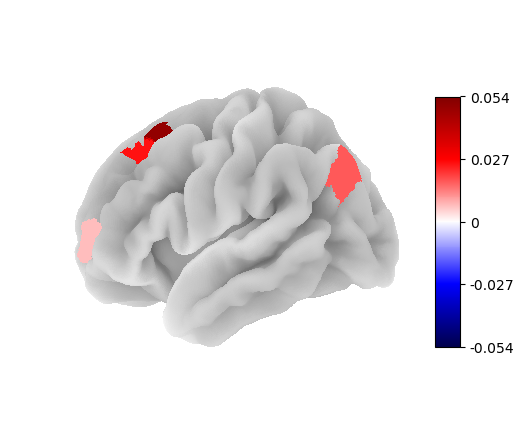

In [49]:
for _, row in brain_reinstatement_diff.iterrows():
    network = row['parcel']
    hemi = row['hemi']
    avg_value = row['group_diff']
    
    mask_file = f"{roi_dir}/sub-all/surface/sub-all_space-fsaverage_hemi-{hemi}_desc-HCPMMP1_parcel-{network}.npy"
    mask = np.load(mask_file)
    
    if hemi == 'lh':
        lh_data[mask] = avg_value
    else:
        rh_data[mask] = avg_value

fig = plotting.plot_surf_stat_map(
    surf_mesh=f'{roi_dir}/sub-all/surface/lh.pial',
    stat_map=lh_data,
    hemi='left',
    view='lateral',
    colorbar=True,
    cmap='seismic',
    # vmin=min_val,
    # vmax=max_val,
    symmetric_cbar=True,
    bg_map=f'{roi_dir}/sub-all/surface/lh.sulc',
    figure=plt.figure(figsize=(5, 5), facecolor='none'),
    alpha=2 
)

# Make axes background transparent
fig.axes[0].patch.set_alpha(0)
# plt.savefig('/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures/curbage_fMRI_desc-RSA_YA-OAs_BrainLeftLateral.png', dpi=300, bbox_inches='tight', transparent=True, facecolor='none')
plt.show()

/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/1309847098.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_stat_map(


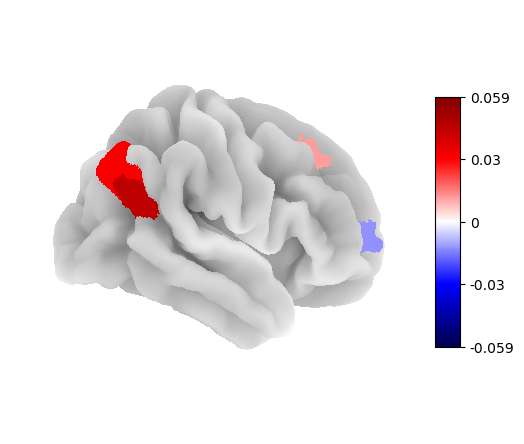

In [51]:
for _, row in brain_reinstatement_diff.iterrows():
    network = row['parcel']
    hemi = row['hemi']
    avg_value = row['group_diff']
    
    mask_file = f"{roi_dir}/sub-all/surface/sub-all_space-fsaverage_hemi-{hemi}_desc-HCPMMP1_parcel-{network}.npy"
    mask = np.load(mask_file)
    
    if hemi == 'lh':
        lh_data[mask] = avg_value
    else:
        rh_data[mask] = avg_value

fig = plotting.plot_surf_stat_map(
    surf_mesh=f'{roi_dir}/sub-all/surface/rh.pial',
    stat_map=rh_data,
    hemi='right',
    view='lateral',
    colorbar=True,
    cmap='seismic',
    symmetric_cbar=True,
    # vmin=min_val,
    # vmax=max_val,
    bg_map=f'{roi_dir}/sub-all/surface/rh.sulc',
    figure=plt.figure(figsize=(5, 5), facecolor='none'),
    alpha=2
)

fig.axes[0].patch.set_alpha(0)
# plt.savefig('/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures/curbage_fMRI_desc-RSA_YA-OAs_BrainRightLateral.png', dpi=300, bbox_inches='tight', transparent=True, facecolor='none')
plt.show()

/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/1667627359.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('seismic')


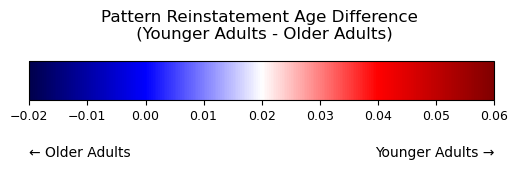

In [52]:
fig, ax = plt.subplots(figsize=(6, 0.5), facecolor='none')

cmap = cm.get_cmap('seismic')
norm = plt.Normalize(vmin=min_val, vmax=max_val)

cbar = fig.colorbar(
    cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=ax,
    orientation='horizontal'
)

cbar.ax.tick_params(labelsize=9)

cbar.ax.text(0.5, 1.5, 'Pattern Reinstatement Age Difference \n (Younger Adults - Older Adults)', ha='center', va='bottom', 
             transform=cbar.ax.transAxes, fontsize=12)

cbar.ax.text(0, -1.2, '← Older Adults', ha='left', va='top', 
             transform=cbar.ax.transAxes, fontsize=10)
cbar.ax.text(1, -1.2, 'Younger Adults →', ha='right', va='top', 
             transform=cbar.ax.transAxes, fontsize=10)

ax.patch.set_alpha(0)

# Save colorbar only
# plt.savefig(
#     '/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures/curbage_fMRI_desc-RSA_YA-OAs_colorbar.png',
#     dpi=300,
#     bbox_inches='tight',
#     transparent=True,
#     facecolor='none',
#     pad_inches=0.1
# )

plt.show()

### Intersubject Correlation

In [69]:
isc = pd.read_pickle(f'/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/github/data/curbage_fMRI_sub-all_group-all_task-all_space-fsaverage_desc-{desc}_5TRshift_ISC.pkl')
isc = isc.groupby(['subject', 'network', 'group', 'comparison'], as_index=False)['fisher_z'].mean()
isc = isc.rename(columns={'fisher_z':'isc'})
isc

,subject,network,group,comparison,isc
0,03,PMN,younger,cross,0.134679
1,03,PMN,younger,within,0.185249
2,04,PMN,younger,cross,0.095708
3,04,PMN,younger,within,0.134982
4,05,PMN,younger,cross,0.112329
...,...,...,...,...,...
95,41,PMN,younger,within,0.201321
96,44,PMN,younger,cross,0.042335
97,44,PMN,younger,within,0.057571
98,45,PMN,younger,cross,0.115568


/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/2977366941.py:90: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{tick:.2f}' for tick in ax.get_yticks()])


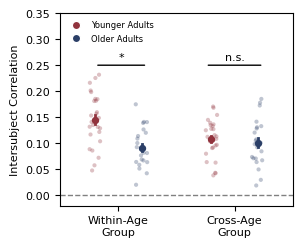

In [ ]:
fig, ax = plt.subplots(figsize=(3, 2.5), facecolor='none')

comparison_order = ['within', 'cross']
comparison_labels = {
    'within': 'Within-Age\nGroup',
    'cross': 'Cross-Age\nGroup'
}

legend_labels = {
    'younger': 'Younger Adults',
    'older': 'Older Adults'
}

sns.pointplot(
    data=isc,
    x='comparison',
    y='isc',
    hue='group',
    palette=group_color, 
    order=comparison_order,
    ci=95,
    markers='o',           
    scale=.6,             
    capsize=0,
    linestyles='none',
    dodge=.4,
    join=False 
)

for line in ax.lines:
    line.set_linewidth(2) 

# Stripplot
sns.stripplot(
    data=isc,
    x='comparison',
    y='isc',
    palette=group_color, 
    hue='group',
    edgecolor="black",
    size=3, 
    jitter=1, 
    zorder=0,
    alpha=0.3,
    order=comparison_order,
    dodge=True
)

# Axis labels and ticks
ax.set_title('', fontsize=8)
ax.set_ylabel('Intersubject Correlation', fontsize=8)
ax.set_xlabel('', fontsize=8)
ax.set_xticks(range(len(comparison_order)))
ax.set_xticklabels([comparison_labels[label] for label in comparison_order])

#legends
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=group_color['younger'], 
           markersize=6, label=legend_labels['younger'], linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=group_color['older'], 
           markersize=6, label=legend_labels['older'], linestyle='None')
]

ax.legend(
    handles=legend_handles,
    title="",
    title_fontsize=8,
    fontsize=6,
    loc="upper left",
    frameon=False 
)

significance_bars = [
    (-0.2, .25, .25, '*'),  
    (.75, 1.25, .25, 'n.s.')        

]

for x_start, x_end, y_pos, sig_label in significance_bars:
    center_x = (x_start + x_end) / 2
    
    ax.annotate('', xy=(x_start, y_pos), xytext=(x_end, y_pos), 
                arrowprops=dict(arrowstyle='-', color='black', linewidth=1))
    
    ax.text(center_x, y_pos + .005, sig_label, ha='center', va='bottom', fontsize=8)

ax.set_ylim(-.02, 0.35)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, zorder=1)
ax.tick_params(labelsize=8)
ax.set_yticklabels([f'{tick:.2f}' for tick in ax.get_yticks()])
# plt.savefig('/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures_2026.02.25/curbage_fMRI_desc-ISC.png', dpi=300, bbox_inches='tight')
plt.show()

#### Brain Figures

In [96]:
brain_isc = pd.read_pickle(f'/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/github/data/curbage_fMRI_sub-all_group-all_task-all_space-fsaverage_desc-{desc}_5TRshift_ISC_Parcels.pkl')
brain_isc = brain_isc.groupby(['subject', 'hemi', 'network', 'parcel', 'group', 'comparison'], as_index=False)['fisher_z'].mean()
brain_isc = brain_isc.rename(columns={'fisher_z':'isc'})
brain_isc.head()

,subject,hemi,network,parcel,group,comparison,isc
0,03,lh,PMN,L_31a,younger,within,0.286451
1,03,lh,PMN,L_31pd,younger,within,0.422121
2,03,lh,PMN,L_31pv,younger,within,0.322419
3,03,lh,PMN,L_7m,younger,within,0.433370
4,03,lh,PMN,L_8Ad,younger,within,0.327171


In [101]:
brain_isc_group = brain_isc.groupby(['group', 'hemi', 'parcel'])['isc'].mean().reset_index()
brain_isc_group.head()

,group,hemi,parcel,isc
0,older,lh,L_31a,0.144094
1,older,lh,L_31pd,0.251386
2,older,lh,L_31pv,0.161738
3,older,lh,L_7m,0.276293
4,older,lh,L_8Ad,0.135465


In [102]:
plot_group = 'younger'

# min_val = -0.02
# max_val = 0.06

lh_data = np.full(163842, np.nan)
rh_data = np.full(163842, np.nan)

/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/2073197460.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_stat_map(


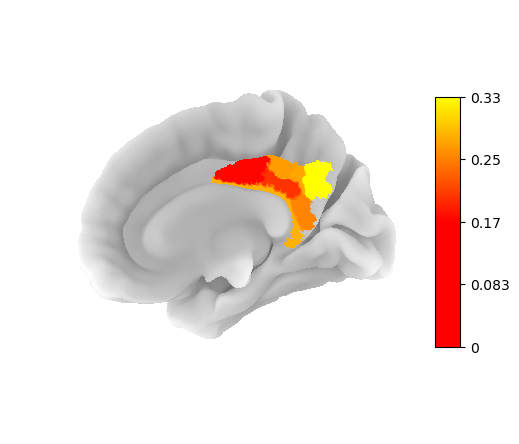

In [107]:
for _, row in brain_isc[brain_isc['group']==plot_group].iterrows():
    network = row['parcel']
    hemi = row['hemi']
    avg_value = row['isc']
    
    mask_file = f"{roi_dir}/sub-all/surface/sub-all_space-fsaverage_hemi-{hemi}_desc-HCPMMP1_parcel-{network}.npy"
    mask = np.load(mask_file)
    
    if hemi == 'lh':
        lh_data[mask] = avg_value
    else:
        rh_data[mask] = avg_value

fig = plotting.plot_surf_stat_map(
    surf_mesh=f'{roi_dir}/sub-all/surface/rh.pial',
    stat_map=rh_data,
    hemi='right',
    view='medial',
    colorbar=True,
    cmap='autumn',
    # vmin=min_val,
    # vmax=max_val,
    symmetric_cbar=False,
    bg_map=f'{roi_dir}/sub-all/surface/rh.sulc',
    figure=plt.figure(figsize=(5, 5), facecolor='none'),
)

fig.axes[0].patch.set_alpha(0)
# plt.savefig(f'/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures/curbage_fMRI_desc-ISC_{plot_group}_BrainRightMedial.png', dpi=300, bbox_inches='tight', transparent=True, facecolor='none')
plt.show()

/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/2773435493.py:20: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_stat_map(


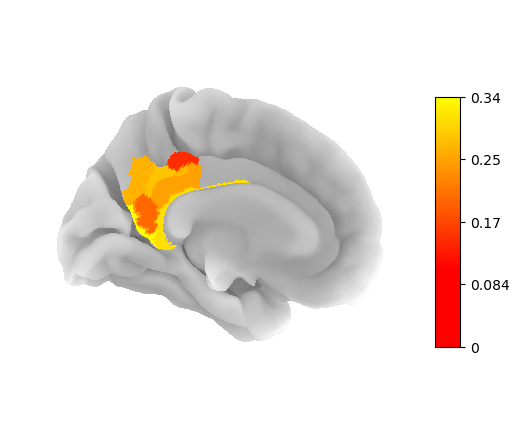

In [108]:
for _, row in brain_isc[brain_isc['group']==plot_group].iterrows():
    network = row['parcel']
    hemi = row['hemi']
    avg_value = row['isc']  # Average value for the group
    
    # Skip L_RSC
    if network == 'L_RSC':
        # print(f"Skipping {network} due to visual artifacts")
        continue
    
    mask_file = f"{roi_dir}/sub-all/surface/sub-all_space-fsaverage_hemi-{hemi}_desc-HCPMMP1_parcel-{network}.npy"
    mask = np.load(mask_file)
    indices = np.where(mask)[0]
    
    if hemi == 'lh':
        lh_data[indices] = avg_value
    else:
        rh_data[indices] = avg_value

fig = plotting.plot_surf_stat_map(
    surf_mesh=f'{roi_dir}/sub-all/surface/lh.pial',
    stat_map=lh_data,
    hemi='left',
    view='medial',
    colorbar=True,
    cmap='autumn',
    # vmin=min_val,
    # vmax=max_val,
    symmetric_cbar=False,
    bg_map=f'{roi_dir}/sub-all/surface/lh.sulc',
    figure=plt.figure(figsize=(5, 5), facecolor='none'),
    alpha=2
)

fig.axes[0].patch.set_alpha(0)
# plt.savefig(f'/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures/curbage_fMRI_desc-ISC_{plot_group}_BrainLeftMedial.png', dpi=300, bbox_inches='tight', transparent=True, facecolor='none')
plt.show()

/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/2374116835.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_stat_map(


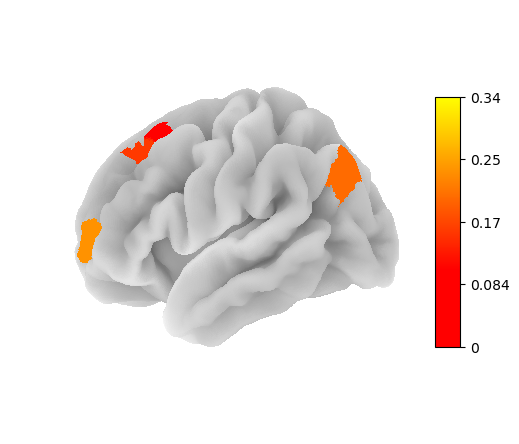

In [109]:
for _, row in brain_isc[brain_isc['group']==plot_group].iterrows():
    network = row['parcel']
    hemi = row['hemi']
    avg_value = row['isc']
    
    mask_file = f"{roi_dir}/sub-all/surface/sub-all_space-fsaverage_hemi-{hemi}_desc-HCPMMP1_parcel-{network}.npy"
    mask = np.load(mask_file)
    
    if hemi == 'lh':
        lh_data[mask] = avg_value
    else:
        rh_data[mask] = avg_value

fig = plotting.plot_surf_stat_map(
    surf_mesh=f'{roi_dir}/sub-all/surface/lh.pial',
    stat_map=lh_data,
    hemi='left',
    view='lateral',
    colorbar=True,
    cmap='autumn',
    # vmin=min_val,
    # vmax=max_val,
    symmetric_cbar=False,
    bg_map=f'{roi_dir}/sub-all/surface/lh.sulc',
    figure=plt.figure(figsize=(5, 5), facecolor='none'),
    alpha=2
)

fig.axes[0].patch.set_alpha(0)
# plt.savefig(f'/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures/curbage_fMRI_desc-ISC_{plot_group}_BrainLeftLateral.png', dpi=300, bbox_inches='tight', transparent=True, facecolor='none')
plt.show()

/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/1754776038.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_stat_map(


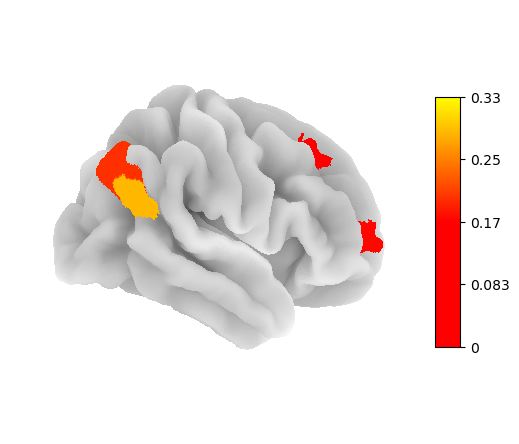

In [110]:
for _, row in brain_isc[(brain_isc['group']==plot_group)].iterrows():
    network = row['parcel']
    hemi = row['hemi']
    avg_value = row['isc']
    
    mask_file = f"{roi_dir}/sub-all/surface/sub-all_space-fsaverage_hemi-{hemi}_desc-HCPMMP1_parcel-{network}.npy"
    mask = np.load(mask_file)
    
    if hemi == 'lh':
        lh_data[mask] = avg_value
    else:
        rh_data[mask] = avg_value

fig = plotting.plot_surf_stat_map(
    surf_mesh=f'{roi_dir}/sub-all/surface/rh.pial',
    stat_map=rh_data,
    hemi='right',
    view='lateral',
    colorbar=True,
    cmap='autumn',
    symmetric_cbar=False,
    # vmin=min_val,
    # vmax=max_val,
    bg_map=f'{roi_dir}/sub-all/surface/rh.sulc',
    figure=plt.figure(figsize=(5, 5), facecolor='none'),
    alpha=2
)

# Make axes background transparent
fig.axes[0].patch.set_alpha(0)
# plt.savefig(f'/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures/curbage_fMRI_desc-ISC_{plot_group}_BrainRightLateral.png', dpi=300, bbox_inches='tight', transparent=True, facecolor='none')
plt.show()

/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/3737321771.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('autumn')


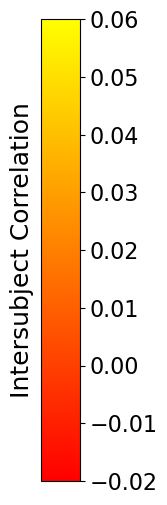

In [111]:
fig, ax = plt.subplots(figsize=(0.5, 6), facecolor='none')

cmap = cm.get_cmap('autumn')
norm = plt.Normalize(vmin=min_val, vmax=max_val)

cbar = fig.colorbar(
    cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=ax,
    orientation='vertical'
)

# Keep the tick values
cbar.ax.tick_params(labelsize=16)

# Title on the left side, vertical
cbar.ax.text(-0.5, 0.5, 'Intersubject Correlation', 
             ha='center', va='center', 
             transform=cbar.ax.transAxes, fontsize=18, rotation=90)

ax.patch.set_alpha(0)

# plt.savefig(
#     '/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures_2026.02.25/curbage_fMRI_desc-ISC_colorbar.png',
#     dpi=300,
#     bbox_inches='tight',
#     transparent=True,
#     facecolor='none',
#     pad_inches=0.1
# )

plt.show()

#### Group Difference

In [120]:
min_val = -0.06
max_val = 0.06

In [114]:
brain_isc_oa = brain_isc_group[brain_isc_group['group']=='older']
brain_isc_ya = brain_isc_group[brain_isc_group['group']=='younger']

brain_isc_diff = brain_isc_oa.merge(
    brain_isc_ya,
    on=['hemi', 'parcel'],
    suffixes=('_oa', '_ya')
)

brain_isc_diff['group_diff'] = brain_isc_diff['isc_ya'] - brain_isc_diff['isc_oa']
brain_isc_diff.head()

,group_oa,hemi,parcel,isc_oa,group_ya,isc_ya,group_diff
0,older,lh,L_31a,0.144094,younger,0.192629,0.048535
1,older,lh,L_31pd,0.251386,younger,0.353686,0.102301
2,older,lh,L_31pv,0.161738,younger,0.277997,0.116259
3,older,lh,L_7m,0.276293,younger,0.377039,0.100746
4,older,lh,L_8Ad,0.135465,younger,0.196164,0.060700


/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/4215939554.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_stat_map(


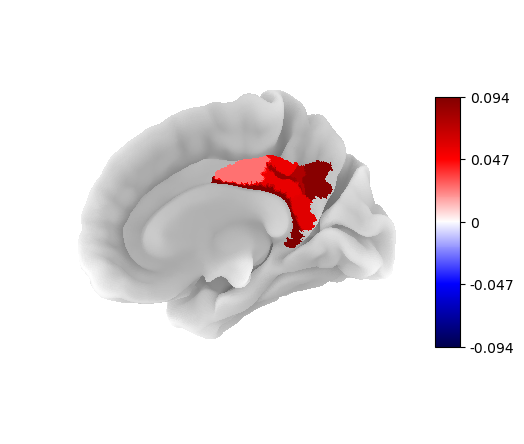

In [116]:
for _, row in brain_isc_diff.iterrows():
    network = row['parcel']
    hemi = row['hemi']
    avg_value = row['group_diff']
    
    mask_file = f"{roi_dir}/sub-all/surface/sub-all_space-fsaverage_hemi-{hemi}_desc-HCPMMP1_parcel-{network}.npy"
    mask = np.load(mask_file)
    
    if hemi == 'lh':
        lh_data[mask] = avg_value
    else:
        rh_data[mask] = avg_value

fig = plotting.plot_surf_stat_map(
    surf_mesh=f'{roi_dir}/sub-all/surface/rh.pial',
    stat_map=rh_data,
    hemi='right',
    view='medial',
    colorbar=True,
    cmap='seismic',
    # vmin=min_val,
    # vmax=max_val,
    symmetric_cbar=True,
    bg_map=f'{roi_dir}/sub-all/surface/rh.sulc',
    figure=plt.figure(figsize=(5, 5), facecolor='none'),
    alpha=2
)

fig.axes[0].patch.set_alpha(0)
# plt.savefig('/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures/curbage_fMRI_desc-ISC_YA-OAs_BrainRightMedial.png', dpi=300, bbox_inches='tight', transparent=True, facecolor='none')
plt.show()

Skipping L_RSC due to visual artifacts


/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/2165307248.py:19: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_stat_map(


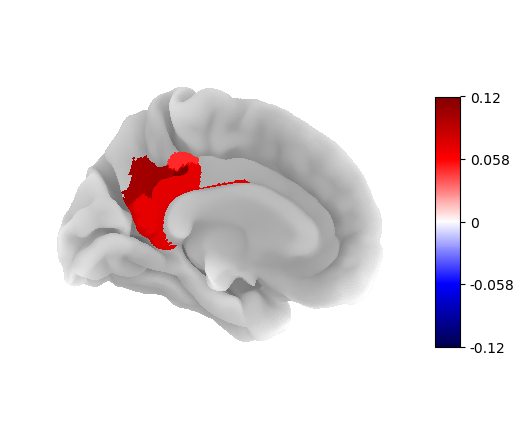

In [117]:
for _, row in brain_isc_diff.iterrows():
    network = row['parcel']
    hemi = row['hemi']
    avg_value = row['group_diff']
    
    if network == 'L_RSC':
        print(f"Skipping {network} due to visual artifacts")
        continue
    
    mask_file = f"{roi_dir}/sub-all/surface/sub-all_space-fsaverage_hemi-{hemi}_desc-HCPMMP1_parcel-{network}.npy"
    mask = np.load(mask_file)
    indices = np.where(mask)[0]
    
    if hemi == 'lh':
        lh_data[indices] = avg_value
    else:
        rh_data[indices] = avg_value

fig = plotting.plot_surf_stat_map(
    surf_mesh=f'{roi_dir}/sub-all/surface/lh.pial',
    stat_map=lh_data,
    hemi='left',
    view='medial',
    colorbar=True,
    cmap='seismic',
    # vmin=min_val,
    # vmax=max_val,
    symmetric_cbar=True,
    bg_map=f'{roi_dir}/sub-all/surface/lh.sulc',
    figure=plt.figure(figsize=(5, 5), facecolor='none'),
    alpha=2
)

fig.axes[0].patch.set_alpha(0)
# plt.savefig('/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures/curbage_fMRI_desc-ISC_YA-OAs_BrainLeftMedial.png', dpi=300, bbox_inches='tight', transparent=True, facecolor='none')
plt.show()

/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/1990095192.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_stat_map(


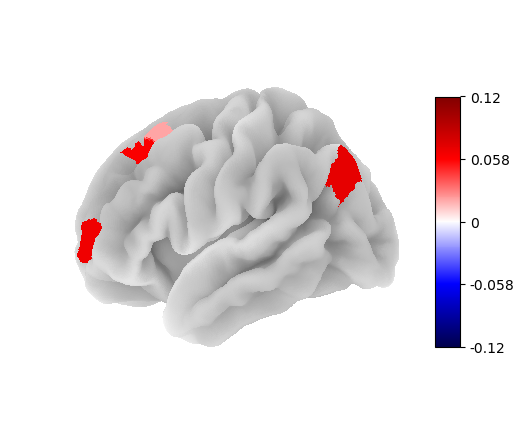

In [118]:
for _, row in brain_isc_diff.iterrows():
    network = row['parcel']
    hemi = row['hemi']
    avg_value = row['group_diff']
    
    mask_file = f"{roi_dir}/sub-all/surface/sub-all_space-fsaverage_hemi-{hemi}_desc-HCPMMP1_parcel-{network}.npy"
    mask = np.load(mask_file)
    
    if hemi == 'lh':
        lh_data[mask] = avg_value
    else:
        rh_data[mask] = avg_value

fig = plotting.plot_surf_stat_map(
    surf_mesh=f'{roi_dir}/sub-all/surface/lh.pial',
    stat_map=lh_data,
    hemi='left',
    view='lateral',
    colorbar=True,
    cmap='seismic',
    # vmin=min_val,
    # vmax=max_val,
    symmetric_cbar=True,
    bg_map=f'{roi_dir}/sub-all/surface/lh.sulc',
    figure=plt.figure(figsize=(5, 5), facecolor='none'),
    alpha=2 
)

# Make axes background transparent
fig.axes[0].patch.set_alpha(0)
# plt.savefig('/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures/curbage_fMRI_desc-ISC_YA-OAs_BrainLeftLateral.png', dpi=300, bbox_inches='tight', transparent=True, facecolor='none')
plt.show()

/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/2909206057.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_stat_map(


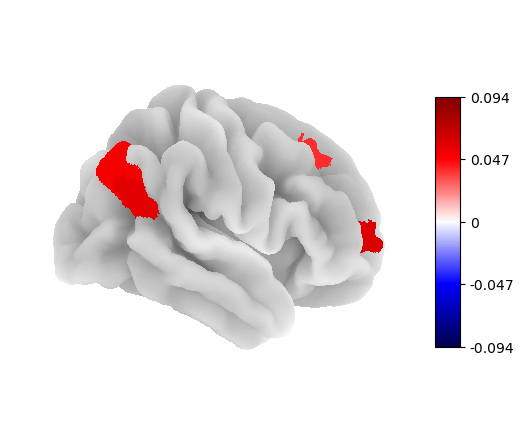

In [119]:
for _, row in brain_isc_diff.iterrows():
    network = row['parcel']
    hemi = row['hemi']
    avg_value = row['group_diff']
    
    mask_file = f"{roi_dir}/sub-all/surface/sub-all_space-fsaverage_hemi-{hemi}_desc-HCPMMP1_parcel-{network}.npy"
    mask = np.load(mask_file)
    
    if hemi == 'lh':
        lh_data[mask] = avg_value
    else:
        rh_data[mask] = avg_value

fig = plotting.plot_surf_stat_map(
    surf_mesh=f'{roi_dir}/sub-all/surface/rh.pial',
    stat_map=rh_data,
    hemi='right',
    view='lateral',
    colorbar=True,
    cmap='seismic',
    symmetric_cbar=True,
    # vmin=min_val,
    # vmax=max_val,
    bg_map=f'{roi_dir}/sub-all/surface/rh.sulc',
    figure=plt.figure(figsize=(5, 5), facecolor='none'),
    alpha=2
)

fig.axes[0].patch.set_alpha(0)
# plt.savefig('/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures/curbage_fMRI_desc-ISC_YA-OAs_BrainRightLateral.png', dpi=300, bbox_inches='tight', transparent=True, facecolor='none')
plt.show()

/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/771607703.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('seismic')


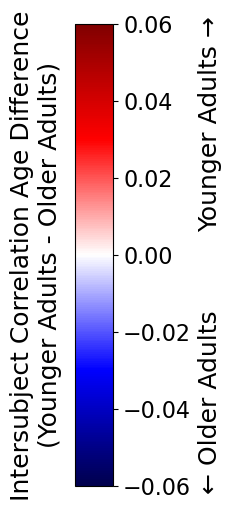

In [121]:
fig, ax = plt.subplots(figsize=(0.5, 6), facecolor='none')

cmap = cm.get_cmap('seismic')
norm = plt.Normalize(vmin=min_val, vmax=max_val)

cbar = fig.colorbar(
    cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=ax,
    orientation='vertical'
)

cbar.ax.tick_params(labelsize=16)

cbar.ax.text(-1, 0.5, 'Intersubject Correlation Age Difference\n(Younger Adults - Older Adults)', 
             ha='center', va='center', 
             transform=cbar.ax.transAxes, fontsize=18, rotation=90)

cbar.ax.text(3.5, .55, 'Younger Adults →', ha='center', va='bottom', 
             transform=cbar.ax.transAxes, fontsize=18, rotation=90)
cbar.ax.text(3.5, .38, '← Older Adults', ha='center', va='top', 
             transform=cbar.ax.transAxes, fontsize=18, rotation=90)

ax.patch.set_alpha(0)

# Save colorbar only
# plt.savefig(
#     '/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures_2026.02.25/curbage_fMRI_desc-ISC_YA-OAs_colorbar.png',
#     dpi=300,
#     bbox_inches='tight',
#     transparent=True,
#     facecolor='none',
#     pad_inches=0.1
# )

plt.show()

#### Circular Shift Permutation

In [129]:
isc_null_dist_oa = np.load('/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/github/data/curbage_fMRI_sub-all_group-older_task-encoding_space-fsaverage_hemi-all_desc-preproc_bold_motion06_zscore_detrend_5TRshift_ISCPermutation.npy')
isc_null_dist_ya = np.load('/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/github/data/curbage_fMRI_sub-all_group-younger_task-encoding_space-fsaverage_hemi-all_desc-preproc_bold_motion06_zscore_detrend_5TRshift_ISCPermutation.npy')
isc_results = pd.read_pickle('/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/github/data/curbage_fMRI_sub-all_group-all_task-encoding_space-fsaverage_hemi-all_desc-preproc_bold_motion06_zscore_detrend_5TRshift_ISCPermutation.pkl')
isc_null_dist = {
    ('older', 'PMN'): isc_null_dist_oa,
    ('younger', 'PMN'): isc_null_dist_ya,
}

In [137]:
plot_group = 'younger'


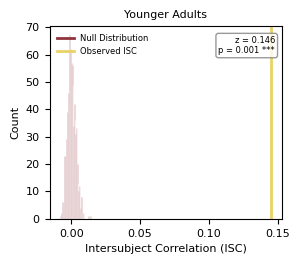

In [138]:
fig, ax = plt.subplots(figsize=(3, 2.5), facecolor='none')

row = isc_results[isc_results.group == plot_group].iloc[0]
null_dist = isc_null_dist[(plot_group, 'PMN')]

ax.hist(
    null_dist, bins=50,
    color=group_color[plot_group],
    alpha=0.8,
    edgecolor='white',
    linewidth=0.5
    )
ax.axvline(
    row.observed_isc_z,
    color='#EAD266',
    linewidth=2)

sig_str = '***' if row.p_value < 0.001 else '**' if row.p_value < 0.01 else '*' if row.p_value < 0.05 else 'n.s.'

ax.set_title(f'{group_labels_single[plot_group]}', fontsize=8)
ax.set_xlabel('Intersubject Correlation (ISC)', fontsize=8)
ax.set_ylabel('Count', fontsize=8)
ax.tick_params(labelsize=8)

ax.text(0.97, 0.95, f'z = {row.observed_isc_z:.3f}\np = {row.p_value:.3f} {sig_str}',
        transform=ax.transAxes, fontsize=6, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='gray', alpha=0.8))

legend_handles = [
    Line2D([0], [0], color=group_color[plot_group], linewidth=2, label='Null Distribution'),
    Line2D([0], [0], color='#EAD266', linewidth=2, label='Observed ISC')
]
ax.legend(handles=legend_handles, fontsize=6, loc='upper left', frameon=False)

# plt.savefig('/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures_2026.02.25/curbage_fMRI_desc-ISCPermutation_{plot_group.capitalize}.png', dpi=300, bbox_inches='tight')
plt.show()

### Encoding-to-Encoding ISPS

In [146]:
isps_enc_enc = pd.read_pickle(f'/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/github/data/curbage_fMRI_sub-all_group-all_task-all_space-fsaverage_desc-{desc}_5TRshift_EncodingToEncodingISPS.pkl')

isps_enc_enc = isps_enc_enc.pivot_table(
    index=['subject', 'network', 'group', 'comparison'],
    columns='match',
    values='fisher_z'
).reset_index()

isps_enc_enc['isps'] = isps_enc_enc['matched'] - isps_enc_enc['mismatched']
isps_enc_enc

match,subject,network,group,comparison,matched,mismatched,isps
0,03,PMN,younger,cross,0.151839,-0.001222,0.153062
1,03,PMN,younger,within,0.206485,-0.001805,0.208290
2,04,PMN,younger,cross,0.121681,-0.002705,0.124386
3,04,PMN,younger,within,0.170611,-0.003394,0.174005
4,05,PMN,younger,cross,0.096141,-0.001957,0.098098
...,...,...,...,...,...,...,...
95,41,PMN,younger,within,0.179569,-0.004912,0.184482
96,44,PMN,younger,cross,0.055331,0.001245,0.054085
97,44,PMN,younger,within,0.055504,0.002216,0.053288
98,45,PMN,younger,cross,0.132127,-0.000867,0.132994


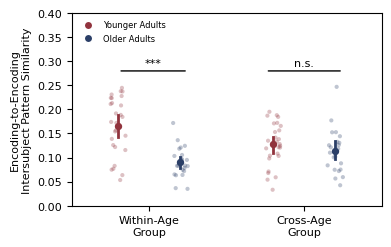

In [147]:
fig, ax = plt.subplots(figsize=(4, 2.5), facecolor='none')

sns.pointplot(
    data=isps_enc_enc,
    x='comparison',
    y='isps',
    hue='group',
    palette=group_color, 
    order=comparison_order,
    ci=95,
    markers='o',           
    scale=.6,             
    capsize=0,
    linestyles='none',
    dodge=.4,
    join=False
)

for line in ax.lines:
    line.set_linewidth(2)

sns.stripplot(
    data=isps_enc_enc,
    x='comparison',
    y='isps',
    palette=group_color, 
    hue='group',
    edgecolor="black",
    size=3, 
    jitter=1, 
    zorder=0,
    alpha=0.3,
    order=comparison_order,
    dodge=True
)

ax.set_title('', fontsize=8)
ax.set_ylabel('Encoding-to-Encoding\nIntersubject Pattern Similarity', fontsize=8)
ax.set_xlabel('', fontsize=8)
ax.set_xticks(range(len(comparison_order)))
ax.set_xticklabels([comparison_labels[label] for label in comparison_order])

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=group_color['younger'], 
           markersize=6, label=legend_labels['younger'], linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=group_color['older'], 
           markersize=6, label=legend_labels['older'], linestyle='None')
]

ax.legend(
    handles=legend_handles,
    title="",
    title_fontsize=8,
    fontsize=6,
    loc="upper left",
    frameon=False 
)

significance_bars = [
    (-0.2, .25, .28, '***'),  
    (.75, 1.25, .28, 'n.s.')     

]

for x_start, x_end, y_pos, sig_label in significance_bars:
    center_x = (x_start + x_end) / 2
    
    ax.annotate('', xy=(x_start, y_pos), xytext=(x_end, y_pos), 
                arrowprops=dict(arrowstyle='-', color='black', linewidth=1))
    
    ax.text(center_x, y_pos + .005, sig_label, ha='center', va='bottom', fontsize=8)

ax.set_ylim(.0, 0.4)
ax.tick_params(labelsize=8)
# plt.savefig('/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures_2026.02.25/curbage_fMRI_desc-ISPSEncodingtoEncodingBetween.png', dpi=300, bbox_inches='tight')
plt.show()

### Encoding-to-Recall ISPS

In [148]:
isps_enc_rec = pd.read_pickle(f'/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/github/data/curbage_fMRI_sub-all_group-all_task-all_space-fsaverage_desc-{desc}_5TRshift_EncodingToRecallISPS.pkl')

isps_enc_rec = isps_enc_rec.pivot_table(
    index=['subject', 'network', 'group', 'comparison'],
    columns='match',
    values='fisher_z'
).reset_index()

isps_enc_rec['isps'] = isps_enc_rec['matched'] - isps_enc_rec['mismatched']
isps_enc_rec

match,subject,network,group,comparison,matched,mismatched,isps
0,03,PMN,younger,cross,0.027146,0.001293,0.025853
1,03,PMN,younger,within,0.036695,0.001254,0.035441
2,04,PMN,younger,cross,0.028621,0.000057,0.028564
3,04,PMN,younger,within,0.042379,0.000535,0.041844
4,05,PMN,younger,cross,0.005673,0.000365,0.005308
...,...,...,...,...,...,...,...
87,41,PMN,younger,within,0.057960,0.001130,0.056831
88,44,PMN,younger,cross,0.035256,-0.000926,0.036181
89,44,PMN,younger,within,0.026969,-0.000557,0.027526
90,45,PMN,younger,cross,0.066514,-0.001784,0.068297


/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/4005983141.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{tick:.2f}' for tick in ax.get_yticks()])


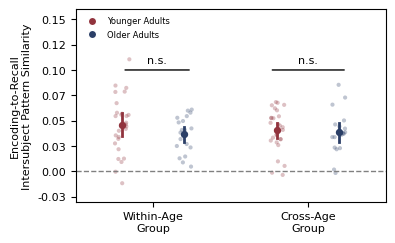

In [150]:
fig, ax = plt.subplots(figsize=(4, 2.5), facecolor='none')

sns.pointplot(
    data=isps_enc_rec,
    x='comparison',
    y='isps',
    hue='group',
    palette=group_color, 
    order=comparison_order,
    ci=95,
    markers='o',           
    scale=.6,             
    capsize=0,
    linestyles='none',
    dodge=.4,
    join=False
)

for line in ax.lines:
    line.set_linewidth(2)

sns.stripplot(
    data=isps_enc_rec,
    x='comparison',
    y='isps',
    palette=group_color, 
    hue='group',
    edgecolor="black",
    size=3, 
    jitter=1, 
    zorder=0,
    alpha=0.3,
    order=comparison_order,
    dodge=True
)

ax.set_title('', fontsize=8)
ax.set_ylabel('Encoding-to-Recall\nIntersubject Pattern Similarity', fontsize=8)
ax.set_xlabel('', fontsize=8)
ax.set_xticks(range(len(comparison_order)))
ax.set_xticklabels([comparison_labels[label] for label in comparison_order])

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=group_color['younger'], 
           markersize=6, label=legend_labels['younger'], linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=group_color['older'], 
           markersize=6, label=legend_labels['older'], linestyle='None')
]

ax.legend(
    handles=legend_handles,
    title="",
    title_fontsize=8,
    fontsize=6,
    loc="upper left",
    frameon=False 
)

significance_bars = [
    (-0.2, .25, .1, 'n.s.'),  
    (.75, 1.25, .1, 'n.s.')        

]

for x_start, x_end, y_pos, sig_label in significance_bars:
    center_x = (x_start + x_end) / 2
    
    ax.annotate('', xy=(x_start, y_pos), xytext=(x_end, y_pos), 
                arrowprops=dict(arrowstyle='-', color='black', linewidth=1))
    
    ax.text(center_x, y_pos + .005, sig_label, ha='center', va='bottom', fontsize=8)

ax.set_ylim(-.03, 0.16)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, zorder=1)
ax.tick_params(labelsize=8)
ax.set_yticklabels([f'{tick:.2f}' for tick in ax.get_yticks()])
# plt.savefig('/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures_2026.02.25/curbage_fMRI_desc-ISPSEncodingtoRecallBetween.png', dpi=300, bbox_inches='tight')
plt.show()

### Recall-to-Recall ISPS

In [151]:
isps_rec_rec = pd.read_pickle(f'/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/github/data/curbage_fMRI_sub-all_group-all_task-all_space-fsaverage_desc-{desc}_5TRshift_RecallToRecallISPS.pkl')

isps_rec_rec = isps_rec_rec.pivot_table(
    index=['subject', 'network', 'group', 'comparison'],
    columns='match',
    values='fisher_z'
).reset_index()

isps_rec_rec['isps'] = isps_rec_rec['matched'] - isps_rec_rec['mismatched']
isps_rec_rec

match,subject,network,group,comparison,matched,mismatched,isps
0,03,PMN,younger,cross,0.037601,-0.000457,0.038058
1,03,PMN,younger,within,0.066395,-0.001343,0.067738
2,04,PMN,younger,cross,0.030371,0.000324,0.030047
3,04,PMN,younger,within,0.053915,-0.000129,0.054044
4,05,PMN,younger,cross,-0.030497,0.001304,-0.031801
...,...,...,...,...,...,...,...
87,41,PMN,younger,within,0.059194,-0.001711,0.060905
88,44,PMN,younger,cross,0.029334,-0.001899,0.031233
89,44,PMN,younger,within,0.053868,-0.001688,0.055556
90,45,PMN,younger,cross,0.061559,-0.000994,0.062554


/var/folders/f7/8sqt961s2bs6gd_1sc0kyg4w0000gn/T/ipykernel_49371/1044168219.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{tick:.2f}' for tick in ax.get_yticks()])


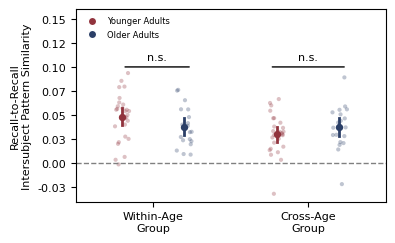

In [ ]:
fig, ax = plt.subplots(figsize=(4, 2.5), facecolor='none')

sns.pointplot(
    data=isps_rec_rec,
    x='comparison',
    y='isps',
    hue='group',
    palette=group_color, 
    order=comparison_order,
    ci=95,
    markers='o',           
    scale=.6,             
    capsize=0,
    linestyles='none',
    dodge=.4,
    join=False
)

for line in ax.lines:
    line.set_linewidth(2)

sns.stripplot(
    data=isps_rec_rec,
    x='comparison',
    y='isps',
    palette=group_color, 
    hue='group',
    edgecolor="black",
    size=3, 
    jitter=1, 
    zorder=0,
    alpha=0.3,
    order=comparison_order,
    dodge=True
)

ax.set_title('', fontsize=8)
ax.set_ylabel('Recall-to-Recall\nIntersubject Pattern Similarity', fontsize=8)
ax.set_xlabel('', fontsize=8)
ax.set_xticks(range(len(comparison_order)))
ax.set_xticklabels([comparison_labels[label] for label in comparison_order])

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=group_color['younger'], 
           markersize=6, label=legend_labels['younger'], linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=group_color['older'], 
           markersize=6, label=legend_labels['older'], linestyle='None')
]

ax.legend(
    handles=legend_handles,
    title="",
    title_fontsize=8,
    fontsize=6,
    loc="upper left",
    frameon=False 
)

significance_bars = [
    (-0.2, .25, .1, 'n.s.'),  
    (.75, 1.25, .1, 'n.s.')        

]

for x_start, x_end, y_pos, sig_label in significance_bars:
    center_x = (x_start + x_end) / 2
    
    ax.annotate('', xy=(x_start, y_pos), xytext=(x_end, y_pos), 
                arrowprops=dict(arrowstyle='-', color='black', linewidth=1))
    
    ax.text(center_x, y_pos + .005, sig_label, ha='center', va='bottom', fontsize=8)

ax.set_ylim(-.04, 0.16)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, zorder=1)
ax.tick_params(labelsize=8)
ax.set_yticklabels([f'{tick:.2f}' for tick in ax.get_yticks()])
# plt.savefig('/Users/aidelarazan/Box Sync/aidelarazan_box/Projects/curbage_fMRI/docs/figures_2026.02.25/curbage_fMRI_desc-ISPSRecalltoRecallBetween.png', dpi=300, bbox_inches='tight')
plt.show()